# 🗺️ บทที่ 7 — จากโมเดลสู่แผนที่จริง (AI + SAM = Palm Map)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/A-Phrom-A/ssb-workshop/blob/main/07_predict_and_map.ipynb)


> **สื่อการสอน Workshop:** การจำแนกพื้นที่ปลูกปาล์มน้ำมันด้วยภาพถ่ายดาวเทียมและ AI  
> ต่อจาก: [บทที่ 6 — Simplify](06_simplify.ipynb)  
> ⚡ **ต้องใช้ GPU** — ไปที่เมนู Runtime → Change runtime type → T4

---

## บทที่ 7 นี้ เราจะทำอะไร?

นี่คือบทสุดท้ายของ Workshop — เราจะ **รวมทุกสิ่งที่เรียนมาทั้ง 6 บท** เข้าด้วยกัน!

![7.1.png](https://raw.githubusercontent.com/A-Phrom-A/ssb-workshop/main/img/7.1.png)

ในบทนี้เราจะ:
1. รัน AI ของเราบนภาพ SAR เพื่อได้ Probability Map
2. ทำความเข้าใจว่า Threshold ทำงานอย่างไร
3. โหลด SAM Segments (เส้นขอบแปลงที่เตรียมไว้)
4. ซ้อน (Overlay) Probability Map กับ SAM Segments
5. ตัดสินใจว่าแปลงไหนเป็นสวนปาล์ม
6. สร้างแผนที่สุดท้ายและ Export

---

## ขั้นตอนที่ 1 — ติดตั้งและเตรียมเครื่องมือ

In [1]:
# เมื่อรัน cell นี้ จะมีหน้าต่างขอ permission ปรากฏขึ้น
# ให้คลิก "Connect to Google Drive" และเลือก Google Account ของคุณ
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/ssb/drive_structure/ch07_predict_and_map'

print("✅ เชื่อมต่อ Google Drive สำเร็จ!")


Mounted at /content/drive
✅ เชื่อมต่อ Google Drive สำเร็จ!


In [46]:
!pip install geoai-py rasterio geopandas opencv-python-headless --quiet

import torch
import geoai

import os

import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from rasterio.features import rasterize

In [29]:


# ── Paths ──
RASTER_DIR  = os.path.join(BASE_DIR, 'data')
MODEL_DIR  = os.path.join(BASE_DIR, 'models')
OUTPUT_DIR = '/content/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ─── Input SAR / Satellite ───
SAR_PATH = os.path.join( RASTER_DIR, 'efd5ad3c-adef-4a2f-af99-ec265ea885ad_1AyLj77.tif')

SAT_PATH = os.path.join( RASTER_DIR, 'satallite_20260425_s52352_z16.tif')

MODEL_PATH  = os.path.join(MODEL_DIR, 'best_model.pth')

SAM_PATH = os.path.join(RASTER_DIR, 'finalsam sim.gpkg')

# ── ค่า Parameters ──
PALM_PROB_THRESHOLD = 0.6   # mean_prob > 0.6 → ถือว่าเป็นปาล์ม (จาก Production)
TILE_SIZE           = 256
STRIDE              = 128
BATCH_SIZE          = 8

# ── Google Drive: ตรวจสอบไฟล์ที่จำเป็น ──
for p in [SAR_PATH, SAT_PATH]:
    status = 'OK' if os.path.exists(p) else 'NOT FOUND'
    print(f'{status}: {os.path.basename(p)}')

print('\n')

OK: Sentinel-1_IW_mosaic_2026_M01_47PQQ_0_0_clif.tif
OK: satallite_20260425_s52352_z16.tif




---

## ขั้นตอนที่ 2 — Sliding Window Inference

ภาพ SAR ต้นฉบับมีขนาดใหญ่เกินกว่า GPU จะประมวลผลได้ในคราวเดียว  
เราจึงใช้เทคนิค **Sliding Window** — ส่องดูทีละส่วน แล้วเลื่อนไปเรื่อยๆ จนครบทั้งภาพ

![7.2.png](https://raw.githubusercontent.com/A-Phrom-A/ssb-workshop/main/img/7.2.png)

In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 2.1 — โหลด Model และรัน Inference
# ═══════════════════════════════════════════════════════════

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

PROB_MAP_PATH = os.path.join(OUTPUT_DIR, 'probability_map.tif')

# Model configuration
ARCHITECTURE = "fpn"
ENCODER_NAME = "resnet50"
NUM_CHANNELS = 2
NUM_CLASSES = 2

print(f'Architecture: {ARCHITECTURE}')
print(f'Encoder: {ENCODER_NAME}')
print(f'Input channels: {NUM_CHANNELS}')
print(f'Classes: {NUM_CLASSES}')

# รัน Inference
print('🔍 กำลังรัน Inference...')

geoai.semantic_segmentation(
    input_path=SAR_PATH,
    output_path=PROB_MAP_PATH,
    model_path=MODEL_PATH,
    architecture=ARCHITECTURE,
    encoder_name=ENCODER_NAME,
    num_channels=NUM_CHANNELS,
    num_classes=NUM_CLASSES,
    window_size=256,
    overlap=128,              # 50% overlap = 128 pixels
    batch_size=8,
    device=device,
)

print(f'✅ บันทึก Probability Map: {PROB_MAP_PATH}')

Device: cuda
Architecture: fpn
Encoder: resnet50
Input channels: 2
Classes: 2
🔍 กำลังรัน Inference...


  0%|          | 0/196 [00:00<?, ?it/s]

✅ บันทึก Probability Map: /content/drive/MyDrive/Colab Notebooks/ssb/drive_structure/ch07_predict_and_map/output/probability_map.tif


Probability Map:
  ขนาด:  1843 x 1804 pixel
  ค่าต่ำสุด: 0.000
  ค่าสูงสุด: 1.000
  ค่าเฉลี่ย: 0.101


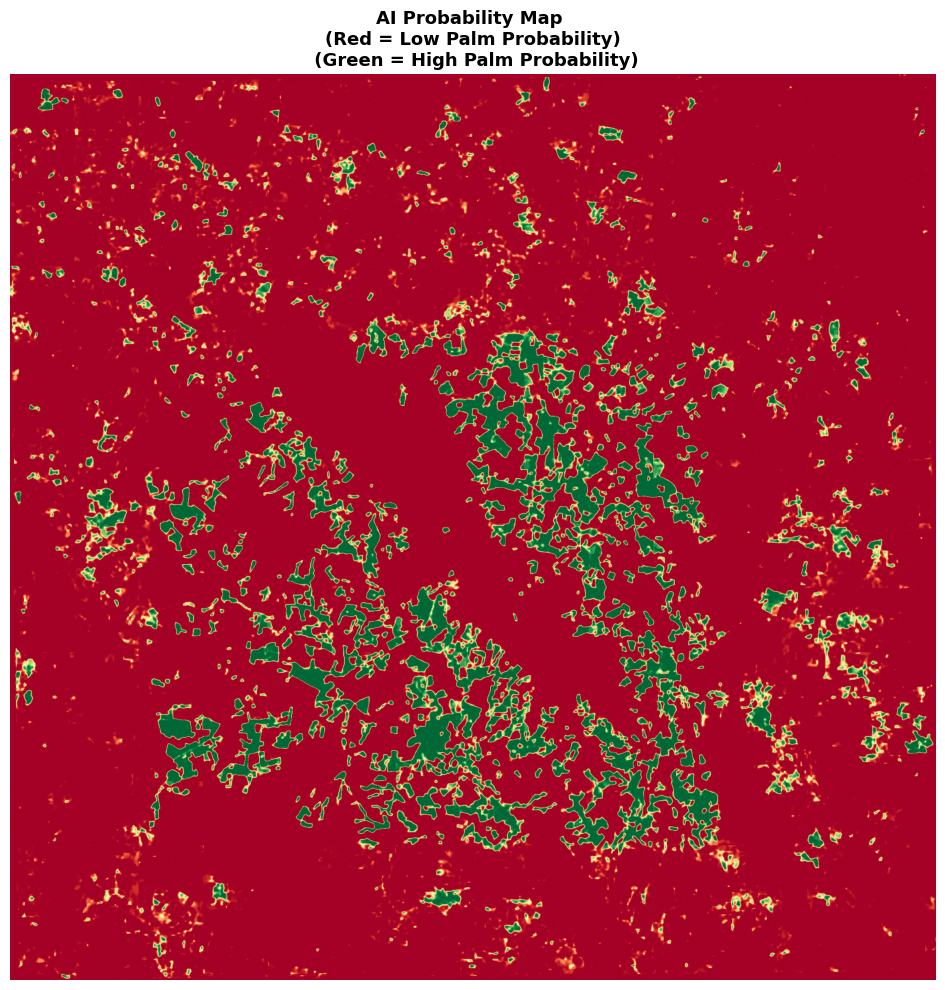



💡 แผนที่นี้ยัง "ไม่ได้ตัดสินใจ" ว่าตรงไหนเป็นปาล์ม
   → ขั้นตอนถัดไป: เลือก Threshold เพื่อแปลงเป็นขาว/ดำ


In [24]:
# ═══════════════════════════════════════════════════════════
# CELL 2.2 — อ่านและแสดง Probability Map
# ═══════════════════════════════════════════════════════════

with rasterio.open(PROB_MAP_PATH) as src:
    prob_map   = src.read(2)      # อ่าน Band 1 → array ขนาดเท่าภาพ SAR
    prob_meta  = src.meta.copy()
    prob_transform = src.transform
    prob_crs   = src.crs

print(f'Probability Map:')
print(f'  ขนาด:  {prob_map.shape[1]} x {prob_map.shape[0]} pixel')
print(f'  ค่าต่ำสุด: {prob_map.min():.3f}')
print(f'  ค่าสูงสุด: {prob_map.max():.3f}')
print(f'  ค่าเฉลี่ย: {prob_map.mean():.3f}')

# แสดง Probability Map เป็น Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(prob_map, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_title('AI Probability Map \n(Red = Low Palm Probability)\n (Green = High Palm Probability)', fontsize=13, fontweight='bold')

ax.axis('off')
plt.tight_layout()
plt.show()
print('\n')
print('💡 แผนที่นี้ยัง "ไม่ได้ตัดสินใจ" ว่าตรงไหนเป็นปาล์ม')
print('   → ขั้นตอนถัดไป: เลือก Threshold เพื่อแปลงเป็นขาว/ดำ')

---

## ขั้นตอนที่ 3 — ทำความเข้าใจ Threshold

ก่อนที่เราจะตัดสินใจว่า pixel ไหนเป็นปาล์ม เราต้องเลือกค่า **Threshold (ค่าตัดสิน)**


![7.3.png](https://raw.githubusercontent.com/A-Phrom-A/ssb-workshop/main/img/7.3.png)

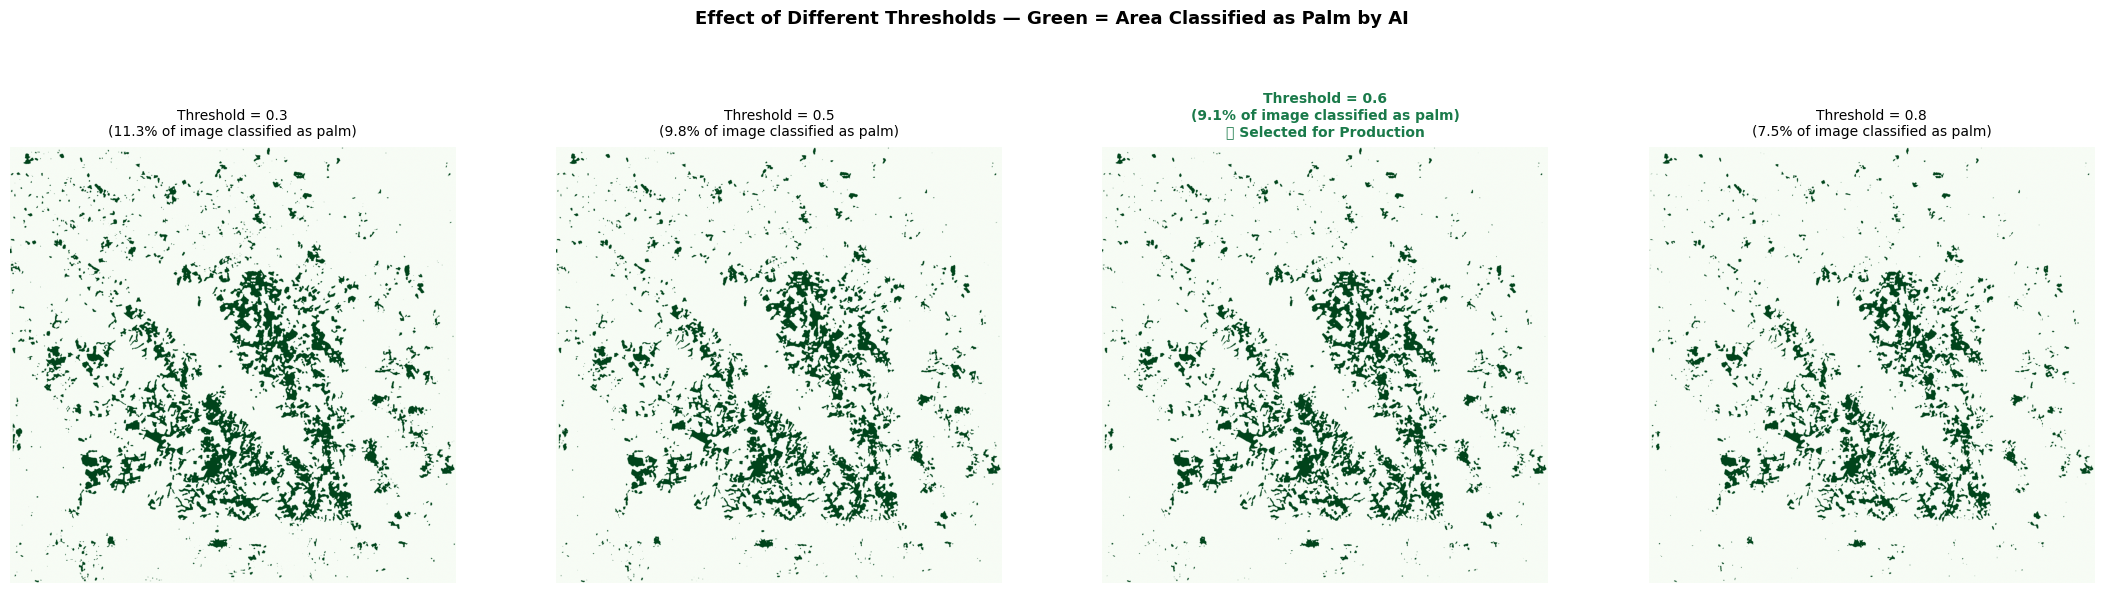

✅ We will use Threshold = 0.6 (Production threshold)


In [25]:
# ═══════════════════════════════════════════════════════════
# CELL 3.1 — เปรียบเทียบ Threshold ต่างๆ
# ═══════════════════════════════════════════════════════════

thresholds = [0.3, 0.5, 0.6, 0.8]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, t in zip(axes, thresholds):
    binary = (prob_map > t).astype(np.uint8)
    pct_palm = binary.mean() * 100

    ax.imshow(binary, cmap='Greens', vmin=0, vmax=1)

    title = f'Threshold = {t}\n({pct_palm:.1f}% of image classified as palm)'

    if t == PALM_PROB_THRESHOLD:
        title += '\n✅ Selected for Production'
        ax.set_title(title, fontsize=10, fontweight='bold', color='#1a7a4a', pad=8)
    else:
        ax.set_title(title, fontsize=10, pad=8)

    ax.axis('off')

plt.suptitle(
    'Effect of Different Thresholds — Green = Area Classified as Palm by AI',
    fontsize=13,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.show()

print(f'✅ We will use Threshold = {PALM_PROB_THRESHOLD} (Production threshold)')

---

## ขั้นตอนที่ 4 — โหลด SAM Segments (เส้นขอบแปลงที่เตรียมไว้)

แทนที่จะ Polygonize จาก Probability Map โดยตรง
เราใช้ **SAM Segments** จากบทที่ 5-6 เป็นเส้นขอบแทน

![7.4-2.png](https://raw.githubusercontent.com/A-Phrom-A/ssb-workshop/main/img/7.4.png)

In [31]:
# ═══════════════════════════════════════════════════════════
# CELL 4.1 — โหลด SAM Segments
# ═══════════════════════════════════════════════════════════

if not os.path.exists(SAM_PATH):
    print(f'❌ ไม่พบไฟล์ SAM: {SAM_PATH}')
    print('   → ตรวจสอบ path ใน Google Drive ด้วยนะครับ')
else:
    sam_gdf = gpd.read_file(SAM_PATH)
    print(f'✅ โหลด SAM Segments เรียบร้อย!')
    print(f'   จำนวน Polygon: {len(sam_gdf):,}')
    print(f'   ระบบพิกัด (CRS): {sam_gdf.crs}')
    print(f'\n')
    print('   5 แปลงแรก:')
    print(sam_gdf.head())

✅ โหลด SAM Segments เรียบร้อย!
   จำนวน Polygon: 2,426
   ระบบพิกัด (CRS): EPSG:3857


   5 แปลงแรก:
    value source                                           geometry
0  1257.0  large  POLYGON ((11419055.881 1383036.906, 11419055.8...
1  1747.0  large  POLYGON ((11420967.173 1383204.089, 11420985.7...
2  1216.0  large  POLYGON ((11421035.024 1382927, 11421038.812 1...
3  1728.0  large  POLYGON ((11419052.707 1383027.294, 11419050.9...
4   931.0  large  POLYGON ((11419105.953 1382759.265, 11419108.4...


In [43]:
with rasterio.open(SAR_PATH) as src: print('SAR:', src.bounds, src.crs)
with rasterio.open(SAT_PATH) as src: print('Satellite:', src.bounds, src.crs)
print('SAM:', sam_gdf.total_bounds, sam_gdf.crs)

SAR: BoundingBox(left=742920.0, bottom=1442260.0, right=779780.0, top=1478340.0) EPSG:32647
Satellite: BoundingBox(left=11271063.230801344, bottom=1459614.5575914492, right=11298889.256197317, top=1488188.493319232) EPSG:3857
SAM: [11417013.19419565  1377924.90301821 11422317.00945538  1383244.70302998] EPSG:3857


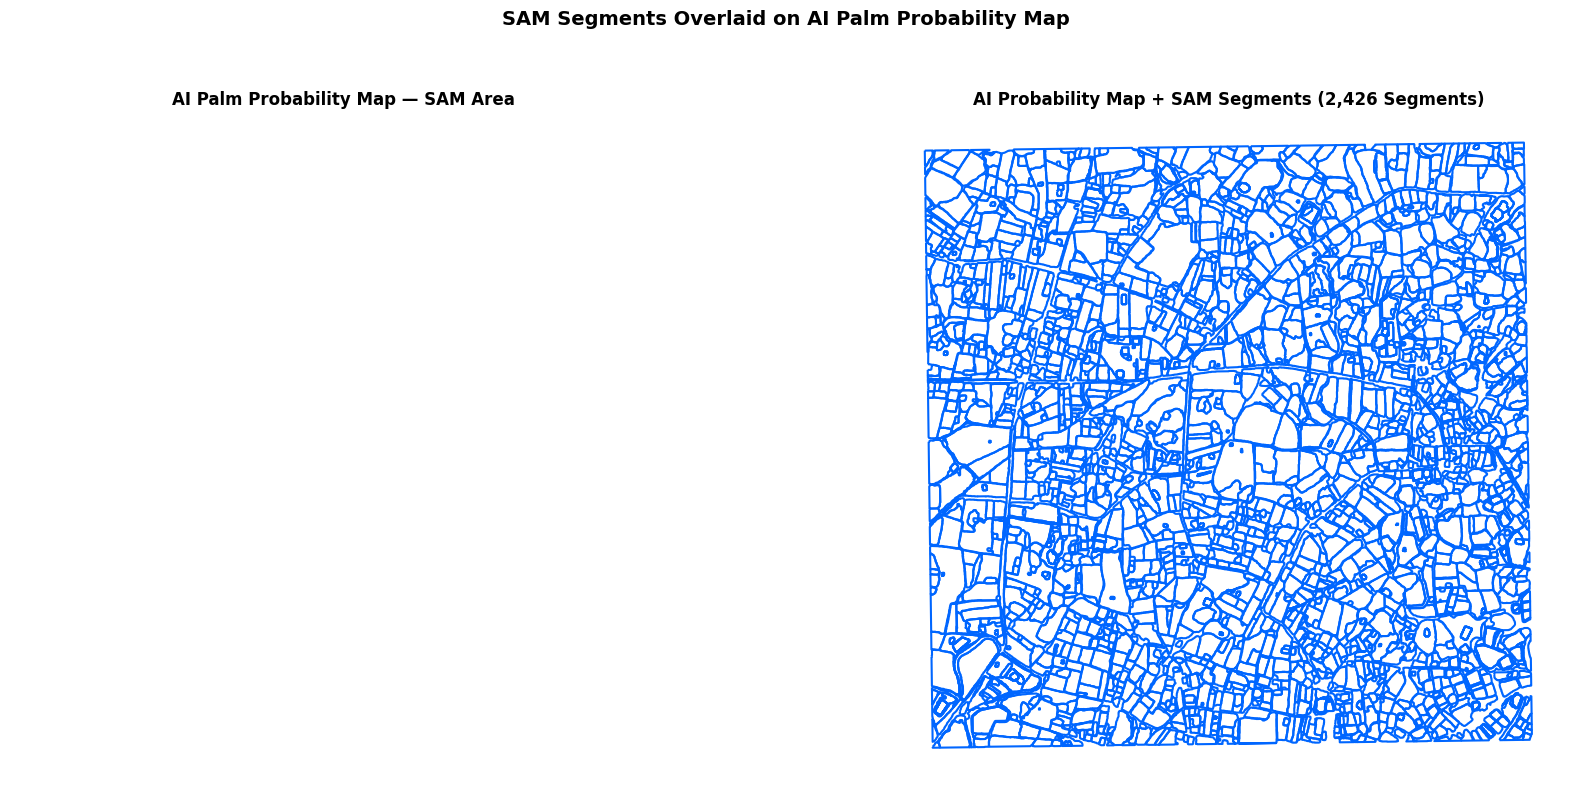

In [42]:
# ═══════════════════════════════════════════════════════════
# CELL 4.2 — Crop Probability Map to SAM Area and Overlay
# ═══════════════════════════════════════════════════════════

sam_gdf_reproj = sam_gdf.to_crs(prob_crs).reset_index(drop=True); sam_gdf_reproj['poly_id'] = sam_gdf_reproj.index + 1
sam_bounds = sam_gdf_reproj.total_bounds
pad_x = (sam_bounds[2] - sam_bounds[0]) * 0.05; pad_y = (sam_bounds[3] - sam_bounds[1]) * 0.05
crop_bounds = [sam_bounds[0]-pad_x, sam_bounds[1]-pad_y, sam_bounds[2]+pad_x, sam_bounds[3]+pad_y]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(prob_map, cmap='RdYlGn', vmin=0, vmax=1, extent=extent, origin='upper', alpha=0.35)
axes[0].set_xlim(crop_bounds[0], crop_bounds[2]); axes[0].set_ylim(crop_bounds[1], crop_bounds[3])
axes[0].set_title('AI Palm Probability Map — SAM Area', fontsize=12, fontweight='bold'); axes[0].axis('off')

axes[1].imshow(prob_map, cmap='RdYlGn', vmin=0, vmax=1, extent=extent, origin='upper', alpha=0.25)
sam_gdf_reproj.boundary.plot(ax=axes[1], color='#0066FF', linewidth=1.5, zorder=10)
axes[1].set_xlim(crop_bounds[0], crop_bounds[2]); axes[1].set_ylim(crop_bounds[1], crop_bounds[3])
axes[1].set_title(f'AI Probability Map + SAM Segments ({len(sam_gdf_reproj):,} Segments)', fontsize=12, fontweight='bold'); axes[1].axis('off')

plt.suptitle('SAM Segments Overlaid on AI Palm Probability Map', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

---

## ขั้นตอนที่ 5 — Zonal Overlay: แต่ละแปลงเป็นปาล์มไหม?

นี่คือหัวใจของบทนี้ — เราจะ **ซ้อนทับ SAM กับ Probability Map** เพื่อตัดสินใจทีละแปลง

### หลักการ (ตามที่ใช้ใน Production จริง)

![7.5.png](https://raw.githubusercontent.com/A-Phrom-A/ssb-workshop/main/img/7.5.png)

In [45]:
# ═══════════════════════════════════════════════════════════
# CELL 5.1 — Rasterize SAM → Instance Mask
# ═══════════════════════════════════════════════════════════

H, W = prob_map.shape

# แต่ละ Polygon ได้ ID เฉพาะ (poly_id = 1, 2, 3, ...)
instance_mask = rasterize(
    shapes=(
        (geom, pid)
        for geom, pid in zip(sam_gdf_reproj.geometry, sam_gdf_reproj['poly_id'])
        if geom is not None and not geom.is_empty
    ),
    out_shape=(H, W),
    transform=prob_transform,
    fill=0,                     # pixel ที่ไม่มีแปลงไหน = 0
    dtype=np.int32,
)

n_ids = len(np.unique(instance_mask)) - 1  # ลบ 0 (background) ออก
print(f'Instance Mask: {instance_mask.shape}')
print(f'จำนวน Polygon ที่ Rasterize ได้: {n_ids:,} แปลง')

Instance Mask: (1804, 1843)
จำนวน Polygon ที่ Rasterize ได้: 0 แปลง


In [53]:
print('Instance Mask min:', instance_mask.min())
print('Instance Mask max:', instance_mask.max())
print('Non-zero pixels:', np.count_nonzero(instance_mask))
print('Unique IDs:', np.unique(instance_mask)[:20])

Instance Mask min: 0
Instance Mask max: 0
Non-zero pixels: 0
Unique IDs: [0]


In [52]:
print('🔍 กำลังคำนวณ mean_prob ต่อแปลง...')
t0 = time.time()

print(f'   Probability Map: {prob_map.shape}')
print(f'   Instance Mask:   {instance_mask.shape}')

unique_ids = np.unique(instance_mask)
unique_ids = unique_ids[unique_ids != 0]
print(f'   SAM polygons:    {len(unique_ids):,}')

if len(unique_ids) == 0:
    raise ValueError('❌ Instance Mask ไม่มี polygon ID — ตรวจสอบ SAM/instance_mask ก่อน')

if prob_map.shape != instance_mask.shape:
    raise ValueError(f'❌ ขนาดไม่ตรงกัน: Probability Map {prob_map.shape} vs Instance Mask {instance_mask.shape}')

palm_records = []

for pid in unique_ids:
    px = prob_map[instance_mask == pid]
    mean_prob = float(px.mean()) if len(px) > 0 else 0.0
    palm_records.append({'poly_id': int(pid), 'mean_prob': round(mean_prob, 4), 'pixel_count': int(len(px)), 'is_palm': mean_prob > PALM_PROB_THRESHOLD})

df_overlay = pd.DataFrame(palm_records)

n_palm = int(df_overlay['is_palm'].sum())
n_not_palm = len(df_overlay) - n_palm

print(f'เสร็จใน {time.time()-t0:.1f} วินาที')
print(f'\n📊 ผลการตัดสิน (Threshold = {PALM_PROB_THRESHOLD}):')
print(f'   ✅ Palm:     {n_palm:,} Segments')
print(f'   ❌ Non-Palm: {n_not_palm:,} Segments')
print(f'   รวมทั้งหมด: {len(df_overlay):,} Segments')

palm_gdf = sam_gdf_reproj.merge(df_overlay, on='poly_id', how='left')
palm_only = palm_gdf[palm_gdf['is_palm'] == True].reset_index(drop=True)

print('\n📈 Distribution of mean_prob:')
print(df_overlay['mean_prob'].describe().round(3))

🔍 กำลังคำนวณ mean_prob ต่อแปลง...
   Probability Map: (1804, 1843)
   Instance Mask:   (1804, 1843)
   SAM polygons:    0


ValueError: ❌ Instance Mask ไม่มี polygon ID — ตรวจสอบ SAM/instance_mask ก่อน

---

## ขั้นตอนที่ 6 — คำนวณพื้นที่และแสดงผลบน Google Satellite

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 6.1 — คำนวณพื้นที่ (ตร.ม. และ ไร่)
# ═══════════════════════════════════════════════════════════

# Project ไปยัง UTM เพื่อให้หน่วยเป็น meter จริง
palm_utm = palm_only.to_crs(palm_only.estimate_utm_crs())
palm_utm['area_m2']     = palm_utm.geometry.area.round(1)
palm_utm['area_rai']    = (palm_utm['area_m2'] / 1600).round(3)
palm_utm['perimeter_m'] = palm_utm.geometry.length.round(1)

# Project กลับมา WGS84 สำหรับ Export
print('palm_final = palm_utm.to_crs('EPSG:4326')

print('📊 สถิติสวนปาล์มที่พบ:')
print(f'   จำนวนแปลง:          {len(palm_final):,} แปลง')
print(f'   พื้นที่รวม:          {palm_final["area_rai"].sum():,.1f} ไร่')
print(f'   พื้นที่เฉลี่ย/แปลง:  {palm_final["area_rai"].mean():.2f} ไร่')
print(f'   พื้นที่น้อยที่สุด:   {palm_final["area_rai"].min():.2f} ไร่')
print(f'   พื้นที่มากที่สุด:   {palm_final["area_rai"].max():.2f} ไร่')

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 6.2 — แสดงผลบน Google Satellite
# ═══════════════════════════════════════════════════════════

with rasterio.open(SAT_PATH) as src:
    s = min(1.0, 1500 / max(src.width, src.height))
    h, w = max(1, int(src.height*s)), max(1, int(src.width*s))
    rgb = np.stack([src.read(i, out_shape=(h, w)) for i in range(1, 4)], axis=-1)
    if rgb.max() > 1: rgb = rgb / 255.0
    sat_crs    = src.crs
    sat_bounds = src.bounds

extent = [sat_bounds.left, sat_bounds.right, sat_bounds.bottom, sat_bounds.top]

# Reproject ผลลัพธ์ → CRS ของ Google Sat
palm_for_plot  = palm_only.to_crs(sat_crs)
all_for_plot   = palm_gdf.to_crs(sat_crs)

fig, axes = plt.subplots(1, 3, figsize=(24, 9))

# แผง 1: Probability Map
print('axes[0].imshow(prob_map, cmap='RdYlGn', vmin=0, vmax=1, extent=extent, origin='upper')
axes[0].set_title('Probability Map
print('(AI Output)', fontsize=12, fontweight='bold')
print('axes[0].axis('off')

# แผง 2: SAM Overlay + Threshold Decision
print('axes[1].imshow(rgb, extent=extent, origin='upper')
all_for_plot[all_for_plot['is_palm']==False].boundary.plot(
    ax=axes[1], color='gray', linewidth=0.3, alpha=0.4)
palm_for_plot.plot(ax=axes[1], color='#35C778', alpha=0.5, linewidth=0)
palm_for_plot.boundary.plot(ax=axes[1], color='#1a7a4a', linewidth=0.7)
axes[1].set_title(f'SAM + AI Decision

print('                  fontsize=12, fontweight='bold')
print('axes[1].axis('off')

# แผง 3: แผนที่สุดท้าย
print('axes[2].imshow(rgb, extent=extent, origin='upper')
palm_for_plot.plot(ax=axes[2], color='#35C778', alpha=0.6, linewidth=0)
palm_for_plot.boundary.plot(ax=axes[2], color='white', linewidth=0.8)
axes[2].set_title(
    f'แผนที่สวนปาล์มสุดท้าย
{len(palm_final):,} แปลง | {palm_final["area_rai"].sum():,.0f} ไร่',
print('    fontsize=12, fontweight='bold')
print('axes[2].axis('off')

print('plt.suptitle('AI + SAM Pipeline: Probability → Decision → Palm Map', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## ขั้นตอนที่ 7 — Export แผนที่สุดท้าย

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 7.1 — Export GeoJSON และ Shapefile
# ═══════════════════════════════════════════════════════════

cols_export = ['poly_id', 'is_palm', 'mean_prob', 'area_m2', 'area_rai', 'perimeter_m', 'geometry']
export_gdf  = palm_final[[c for c in cols_export if c in palm_final.columns]].copy()

# GeoJSON (เปิดใน QGIS, Google Earth, Mapbox ได้เลย)
print('out_geojson = os.path.join(OUTPUT_DIR, 'palm_parcels.geojson')
print('export_gdf.to_file(out_geojson, driver='GeoJSON')
print(f'✅ GeoJSON: {out_geojson}')

# GeoPackage (ฟอร์แมตใหม่ แทน Shapefile)
print('out_gpkg = os.path.join(OUTPUT_DIR, 'palm_parcels.gpkg')
print('export_gdf.to_file(out_gpkg, driver='GPKG')
print(f'✅ GeoPackage: {out_gpkg}')

# สรุปสุดท้าย
print('\n')
' + '='*55)
print('🌴 สรุป Pipeline ทั้งหมด')
print('='*55)
print(f'  SAM Segments (input):    {len(sam_gdf):,}')
print(f'  Palm confirmed (>{PALM_PROB_THRESHOLD}): {len(palm_final):,}')
print(f'  พื้นที่ปาล์มรวม:          {palm_final["area_rai"].sum():,.1f} ไร่')
print(f'  พื้นที่เฉลี่ยต่อแปลง:     {palm_final["area_rai"].mean():.2f} ไร่')

---

## 🎉  ทำสำเร็จแล้ว!
